# 260523 — Density-ViT-MAE inspection

Companion to `260520_density_mae_inspect.ipynb` — same recipe, but the encoder is a pure 3D ViT (`DensityViTMAE`, see `voxbind/models/density_vit.py`).

1. **Density** — ground truth (clean blur of atom voxels) vs masked input vs model prediction.
2. **Structure** — target ligand+pocket atom voxels vs predicted (channel sums).
3. **Per-channel atoms** — 11 channels target vs predicted (lig: 7, poc: 4).
4. **Quantitative split** — per-source MSE on atoms-present vs background voxels.
5. **ViT-only: attention rollout** — per-patch importance reduced from the 6-layer attention stack, overlaid on density.

Mask ratio 0.6, block size 8³ vox (= 2³ Å). All numbers per-voxel z-scored.

Default `EXP_DIR` points at `260522_density_vit_mae_pretrain/`. Point at older epoch checkpoints (`checkpoint_e0050.pth.tar` etc.) to compare ViT-feature evolution.

In [1]:
# ── imports + paths ──────────────────────────────────────────────────────
import sys, os, types
VOX_ROOT = '/home/shpark/prj-denovo/VoxBind'
if VOX_ROOT not in sys.path:
    sys.path.insert(0, VOX_ROOT)

import numpy as np
import torch
import matplotlib.pyplot as plt
from omegaconf import OmegaConf

from voxbind.models.density_vit import DensityViTMAE
from voxbind.models.density_mae import gaussian_blur3d, per_sample_zscore
from voxbind.dataset.crossdocked import DatasetCrossdocked
from voxbind.voxelizer import Voxelizer

device = torch.device('cuda:7' if torch.cuda.is_available() else 'cpu')
torch.set_grad_enabled(False)
print('device:', device)

device: cuda:7


In [2]:
# ── knobs ────────────────────────────────────────────────────────────────
EXP_DIR = f'{VOX_ROOT}/voxbind/exps/260522_density_vit_mae_pretrain'
CKPT_PATH = f'{EXP_DIR}/checkpoint.pth.tar'   # or checkpoint_e0050.pth.tar etc.
DATA_DIR = f'{VOX_ROOT}/voxbind/dataset/data'

SAMPLE_IDX = 7        # which val sample to visualize (0..99); 7 matches the cnn-MAE inspect default
SLICE_AXIS = 'z'      # 'x', 'y', or 'z'
SLICE_OFFSET = 0      # offset from grid center (in voxels)
SEED_MASK = 0         # reproducible block mask  (same as cnn-MAE inspect for direct comparison)
SEED_NOISE = 1        # reproducible additive noise

# Match the training config (configs/config_train_density_vit_mae.yaml > mae)
SIGMA_BLUR_A = 0.55   # midpoint of [0.30, 0.80] Å
SIGMA_NOISE = 0.05
BLOCK_SIZE = 8
MASK_RATIO = 0.60
RESOLUTION = 0.25     # Å / voxel
GRID_DIM = 64
STRUCT_POS_THRESH = 0.05
print(f'σ_blur = {SIGMA_BLUR_A} Å = {SIGMA_BLUR_A / RESOLUTION:.2f} vox')

σ_blur = 0.55 Å = 2.20 vox


In [3]:
# ── load model from checkpoint ───────────────────────────────────────────
ckpt = torch.load(CKPT_PATH, map_location=device, weights_only=False)
cfg = ckpt['cfg'] if 'cfg' in ckpt else None
print('ckpt epoch:', ckpt.get('epoch'), '| global_step:', ckpt.get('global_step'))
if cfg is not None:
    print('model cfg:', OmegaConf.to_container(cfg.model, resolve=True))

model = DensityViTMAE(
    grid_dim=int(cfg.vox.grid_dim) if cfg is not None else GRID_DIM,
    patch_size=int(cfg.model.patch_size) if cfg is not None else 8,
    n_channels=int(cfg.model.n_channels) if cfg is not None else 32,
    dim=int(cfg.model.dim) if cfg is not None else 192,
    depth=int(cfg.model.depth) if cfg is not None else 6,
    n_heads=int(cfg.model.heads) if cfg is not None else 6,
    mlp_ratio=int(cfg.model.mlp_ratio) if cfg is not None else 4,
    dropout=float(cfg.model.dropout) if cfg is not None else 0.1,
    n_struct_channels=int(cfg.model.n_struct_channels) if cfg is not None else 11,
).to(device).eval()

sd = ckpt.get('state_dict_ema', ckpt.get('state_dict'))
sd = {k.replace('module.', '').replace('_orig_mod.', ''): v for k, v in sd.items()}
missing, unexpected = model.load_state_dict(sd, strict=False)
print('missing keys:', len(missing), '| unexpected keys:', len(unexpected))
print(f'params: {sum(p.numel() for p in model.parameters()) / 1e6:.3f}M')
print(f'token grid: {model.encoder.g_p}³ = {model.encoder.n_tokens} tokens; patch_size={model.encoder.patch_size}')

ckpt epoch: 99 | global_step: 104000
model cfg: {'model_name': 'density_vit_mae', 'n_channels': 32, 'patch_size': 8, 'dim': 192, 'depth': 6, 'heads': 6, 'mlp_ratio': 4, 'dropout': 0.1, 'n_struct_channels': 11}
missing keys: 0 | unexpected keys: 0
params: 4.466M
token grid: 8³ = 512 tokens; patch_size=8


In [4]:
# ── load + voxelize one val sample ───────────────────────────────────────
dset_val = DatasetCrossdocked(
    data_dir=DATA_DIR, split='val', aug=False, small=False,
    ligand_radius=0.5, pocket_radius=-1,
)
print('val set size:', len(dset_val))
sample = dset_val[SAMPLE_IDX]
print('sample id:', sample['ligand']['id'], '|', sample['pocket']['id'])

voxelizer = Voxelizer(
    grid_dim=GRID_DIM, resolution=RESOLUTION, cubes_around=8, device=device,
)
lig = {k: sample['ligand'][k].unsqueeze(0).to(device)
       for k in ('coords', 'radius', 'atoms_channel')}
poc = {k: sample['pocket'][k].unsqueeze(0).to(device)
       for k in ('coords', 'radius', 'atoms_channel')}
v_lig = voxelizer(lig, num_channels=7)      # (1, 7, G, G, G)
v_poc = voxelizer(poc, num_channels=4)      # (1, 4, G, G, G)
print('v_lig:', tuple(v_lig.shape), 'v_poc:', tuple(v_poc.shape))

val set size: 100
sample id: BRD9_HUMAN_133_241_0/4yyg_A_rec_4nqn_y1z_lig_tt_docked_1.sdf | BRD9_HUMAN_133_241_0/4yyg_A_rec_4nqn_y1z_lig_tt_docked_1_pocket10.pdb
v_lig: (1, 7, 64, 64, 64) v_poc: (1, 4, 64, 64, 64)


In [5]:
# ── build synthetic density + mask (same recipe as the trainer) ──────────
g_mask = torch.Generator(device=device).manual_seed(SEED_MASK)
g_noise = torch.Generator(device=device).manual_seed(SEED_NOISE)

atoms_sum = v_lig.sum(dim=1, keepdim=True) + v_poc.sum(dim=1, keepdim=True)
sigma_vox = SIGMA_BLUR_A / RESOLUTION
d_clean = gaussian_blur3d(atoms_sum, sigma_vox)
d_clean = per_sample_zscore(d_clean)
d_noisy = d_clean + torch.randn(d_clean.shape, device=device, generator=g_noise) * SIGMA_NOISE

gb = GRID_DIM // BLOCK_SIZE
blocks = torch.rand(1, 1, gb, gb, gb, device=device, generator=g_mask) < MASK_RATIO
mask = blocks.repeat_interleave(BLOCK_SIZE, 2)\
             .repeat_interleave(BLOCK_SIZE, 3)\
             .repeat_interleave(BLOCK_SIZE, 4)
d_in = d_noisy * (~mask).to(d_noisy.dtype)
target_str = torch.cat([v_lig, v_poc], dim=1)

print(f'mask fraction: {mask.float().mean().item():.3f}  (target {MASK_RATIO})')
print(f'd_clean stats: mean={d_clean.mean().item():+.3f}  std={d_clean.std().item():.3f}  '
      f'min={d_clean.min().item():+.2f}  max={d_clean.max().item():+.2f}')

mask fraction: 0.580  (target 0.6)
d_clean stats: mean=+0.000  std=1.000  min=-0.83  max=+3.63


In [6]:
# ── forward through the model ────────────────────────────────────────────
d_hat, a_hat = model(d_in)
print('d_hat:', tuple(d_hat.shape), 'a_hat:', tuple(a_hat.shape))

m = mask.float()
L_dens_masked = (((d_hat - d_clean) ** 2) * m).sum() / m.sum().clamp(min=1)
L_str_all    = ((a_hat - target_str) ** 2).mean()
print(f'sample L_dens (masked only): {L_dens_masked.item():.5f}')
print(f'sample L_str  (all voxels):  {L_str_all.item():.5f}')

print(f'\nper-source split (threshold {STRUCT_POS_THRESH}):')
for name, tgt, pred in [
    ('lig', target_str[0, :7], a_hat[0, :7]),
    ('poc', target_str[0, 7:], a_hat[0, 7:]),
]:
    pos = tgt > STRUCT_POS_THRESH
    pos_frac = pos.float().mean().item()
    mse_on  = ((pred[pos]  - tgt[pos])  ** 2).mean().item() if pos.any() else float('nan')
    mse_off = ((pred[~pos] - tgt[~pos]) ** 2).mean().item()
    print(
        f'  {name}: pos-frac={pos_frac:.4f}  '
        f'peak tgt={tgt.max().item():.3f} pred={pred.max().item():.3f}  '
        f'MSE@on={mse_on:.4f}  MSE@off={mse_off:.6f}'
    )

d_hat: (1, 1, 64, 64, 64) a_hat: (1, 11, 64, 64, 64)
sample L_dens (masked only): 0.00452
sample L_str  (all voxels):  0.00171

per-source split (threshold 0.05):
  lig: pos-frac=0.0028  peak tgt=0.992 pred=0.683  MSE@on=0.0217  MSE@off=0.000694
  poc: pos-frac=0.2091  peak tgt=1.000 pred=1.101  MSE@on=0.0045  MSE@off=0.003099


In [7]:
# ── slicing helper ───────────────────────────────────────────────────────
def take_slice(vol, axis='z', offset=0):
    arr = vol.detach().cpu().numpy() if torch.is_tensor(vol) else vol
    G = arr.shape[-1]
    idx = G // 2 + offset
    if axis == 'x':
        return arr[idx, :, :]
    elif axis == 'y':
        return arr[:, idx, :]
    elif axis == 'z':
        return arr[:, :, idx]
    raise ValueError(axis)

def show(ax, img, title, cmap='gray', vmin=None, vmax=None):
    im = ax.imshow(img.T, origin='lower', cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_title(title, fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])
    return im

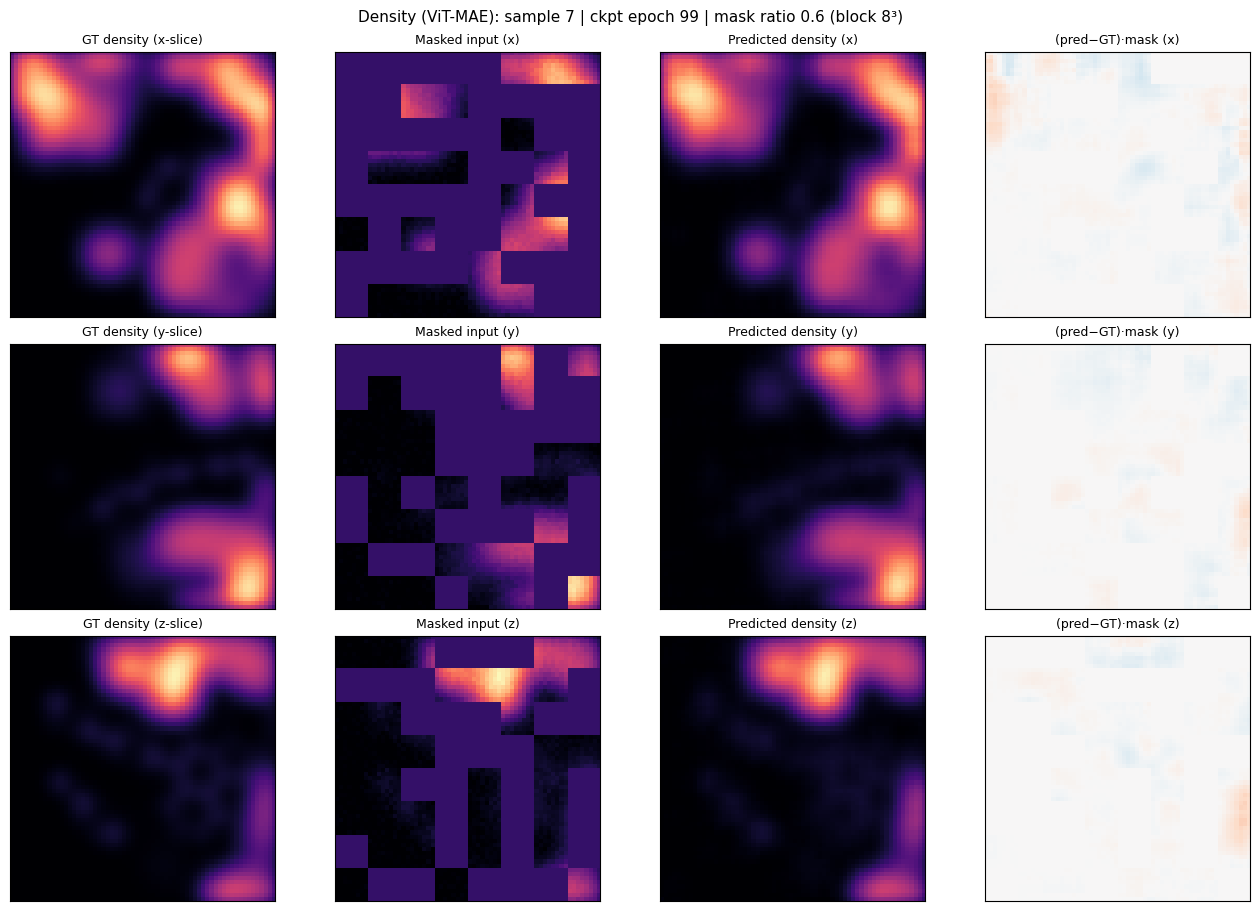

In [8]:
# ── plot 1: density — ground truth | masked input | predicted | diff ────
d_clean_3d = d_clean[0, 0]
d_in_3d    = d_in[0, 0]
d_hat_3d   = d_hat[0, 0]
mask_3d    = mask[0, 0]

vlo = d_clean_3d.min().item()
vhi = d_clean_3d.max().item()

fig, axes = plt.subplots(3, 4, figsize=(13, 9), constrained_layout=True)
for i, ax_name in enumerate(['x', 'y', 'z']):
    show(axes[i, 0], take_slice(d_clean_3d, ax_name, SLICE_OFFSET),
         f'GT density ({ax_name}-slice)', cmap='magma', vmin=vlo, vmax=vhi)
    show(axes[i, 1], take_slice(d_in_3d, ax_name, SLICE_OFFSET),
         f'Masked input ({ax_name})', cmap='magma', vmin=vlo, vmax=vhi)
    show(axes[i, 2], take_slice(d_hat_3d, ax_name, SLICE_OFFSET),
         f'Predicted density ({ax_name})', cmap='magma', vmin=vlo, vmax=vhi)
    diff = (d_hat_3d - d_clean_3d) * mask_3d.float()
    show(axes[i, 3], take_slice(diff, ax_name, SLICE_OFFSET),
         f'(pred−GT)·mask ({ax_name})', cmap='RdBu_r', vmin=-1.5, vmax=1.5)
fig.suptitle(
    f"Density (ViT-MAE): sample {SAMPLE_IDX} | ckpt epoch {ckpt.get('epoch')} | "
    f"mask ratio {MASK_RATIO} (block {BLOCK_SIZE}³)",
    fontsize=11,
)
plt.show()

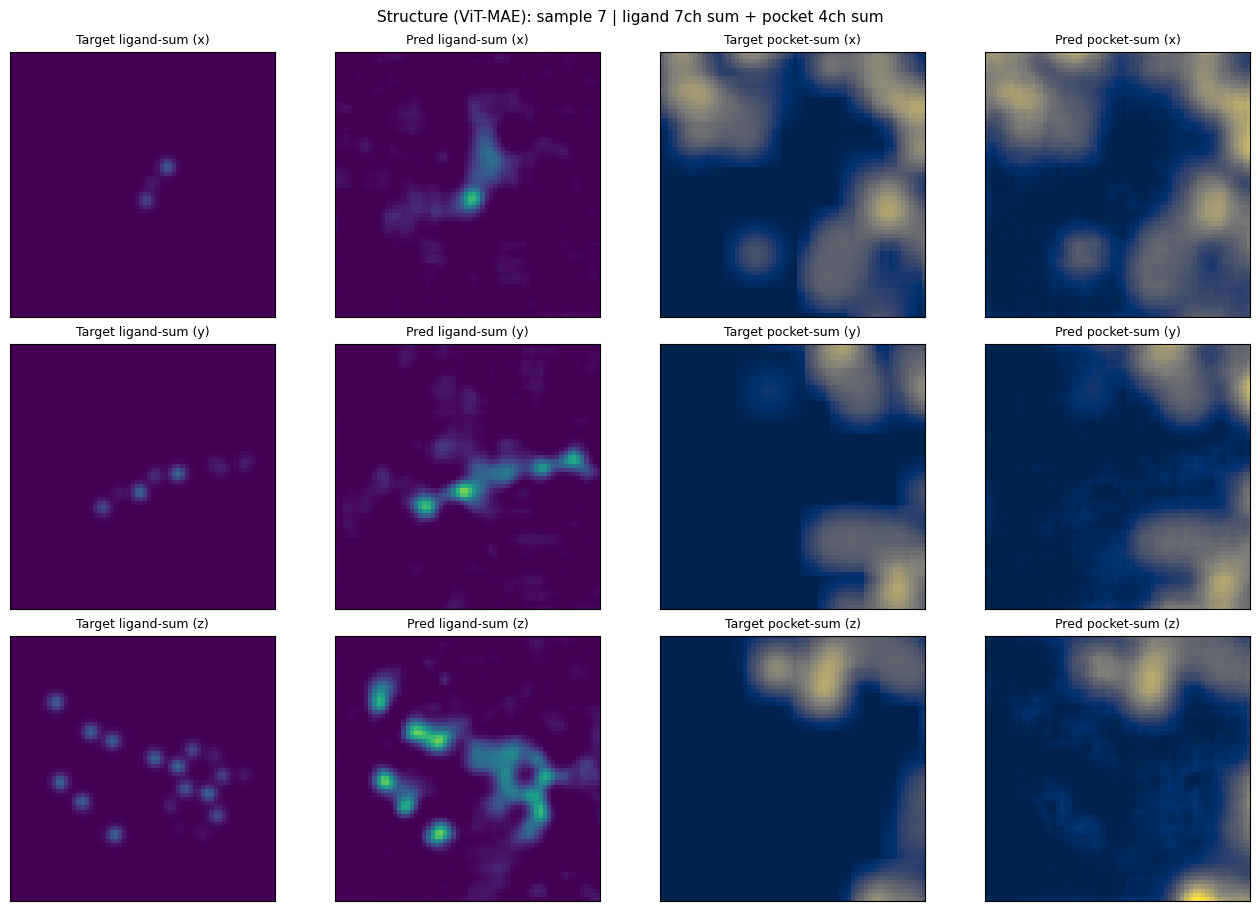

In [9]:
# ── plot 2: structure — ligand-sum and pocket-sum, target vs predicted ──
tgt_lig = target_str[0, :7].sum(0)
tgt_poc = target_str[0, 7:].sum(0)
pred_lig = a_hat[0, :7].sum(0)
pred_poc = a_hat[0, 7:].sum(0)

vmax_lig = max(tgt_lig.max().item(), pred_lig.max().item())
vmax_poc = max(tgt_poc.max().item(), pred_poc.max().item())

fig, axes = plt.subplots(3, 4, figsize=(13, 9), constrained_layout=True)
for i, ax_name in enumerate(['x', 'y', 'z']):
    show(axes[i, 0], take_slice(tgt_lig, ax_name, SLICE_OFFSET),
         f'Target ligand-sum ({ax_name})', cmap='viridis', vmin=0, vmax=vmax_lig)
    show(axes[i, 1], take_slice(pred_lig, ax_name, SLICE_OFFSET),
         f'Pred ligand-sum ({ax_name})', cmap='viridis', vmin=0, vmax=vmax_lig)
    show(axes[i, 2], take_slice(tgt_poc, ax_name, SLICE_OFFSET),
         f'Target pocket-sum ({ax_name})', cmap='cividis', vmin=0, vmax=vmax_poc)
    show(axes[i, 3], take_slice(pred_poc, ax_name, SLICE_OFFSET),
         f'Pred pocket-sum ({ax_name})', cmap='cividis', vmin=0, vmax=vmax_poc)
fig.suptitle(
    f'Structure (ViT-MAE): sample {SAMPLE_IDX} | ligand 7ch sum + pocket 4ch sum',
    fontsize=11,
)
plt.show()

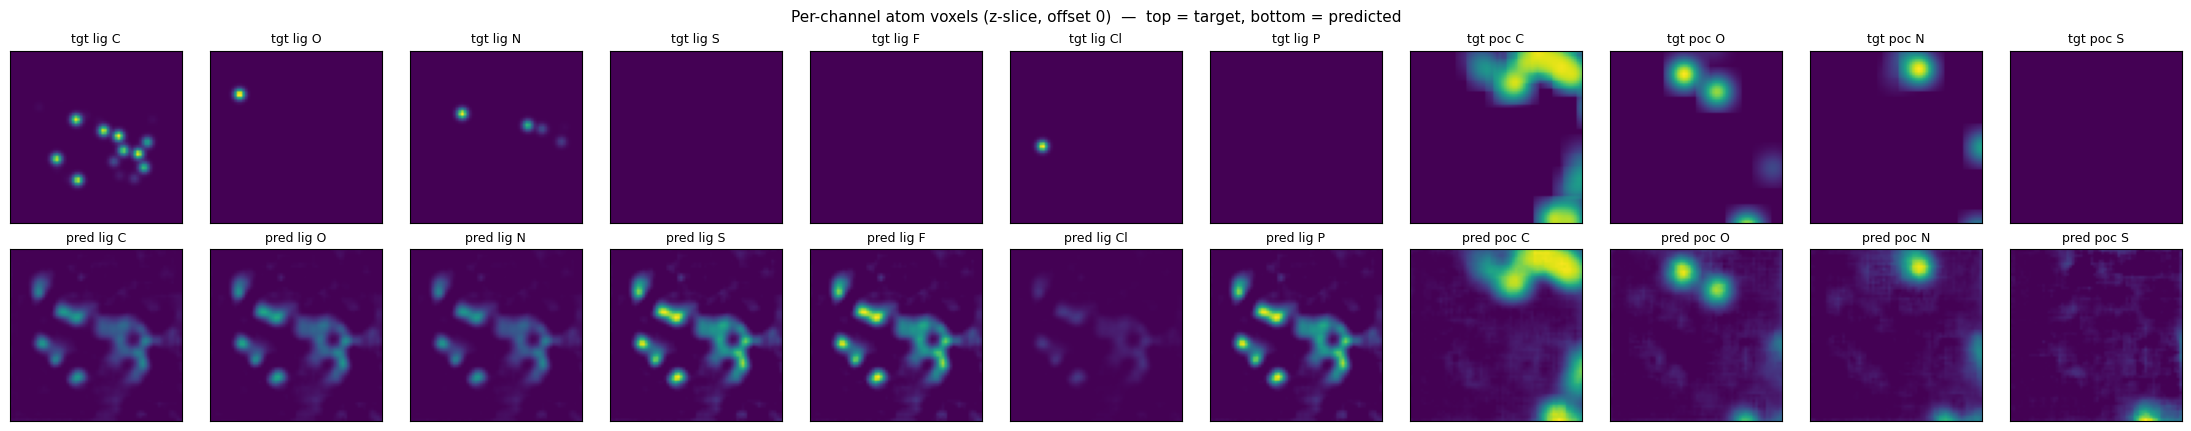

In [10]:
# ── plot 3: all 11 channels — target (top) vs predicted (bottom) ────────
from voxbind.constants import ELEMENTS_HASH_CROSSDOCKED
elem_names = list(ELEMENTS_HASH_CROSSDOCKED.keys())
lig_names = [f'lig {elem_names[i]}' for i in range(7)]
poc_names = [f'poc {elem_names[i]}' for i in range(4)]
chan_names = lig_names + poc_names

fig, axes = plt.subplots(2, 11, figsize=(22, 4.2), constrained_layout=True)
for c in range(11):
    tgt = take_slice(target_str[0, c], SLICE_AXIS, SLICE_OFFSET)
    pred = take_slice(a_hat[0, c], SLICE_AXIS, SLICE_OFFSET)
    vmax = max(tgt.max(), pred.max(), 1e-3)
    show(axes[0, c], tgt, f'tgt {chan_names[c]}', cmap='viridis', vmin=0, vmax=vmax)
    show(axes[1, c], pred, f'pred {chan_names[c]}', cmap='viridis', vmin=0, vmax=vmax)
fig.suptitle(
    f'Per-channel atom voxels ({SLICE_AXIS}-slice, offset {SLICE_OFFSET})  —  '
    f'top = target, bottom = predicted',
    fontsize=11,
)
plt.show()

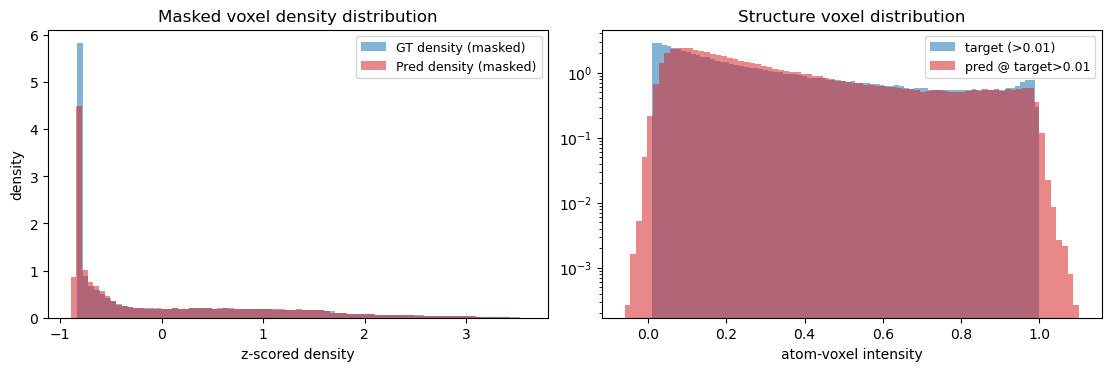

In [11]:
# ── histogram: pred vs target voxel-value distributions ─────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), constrained_layout=True)

m_flat = mask_3d.bool().flatten().cpu()
gt_d = d_clean_3d.flatten().cpu()[m_flat].numpy()
pr_d = d_hat_3d.flatten().cpu()[m_flat].numpy()
axes[0].hist(gt_d, bins=80, alpha=0.55, label='GT density (masked)', color='C0', density=True)
axes[0].hist(pr_d, bins=80, alpha=0.55, label='Pred density (masked)', color='C3', density=True)
axes[0].set_xlabel('z-scored density'); axes[0].set_ylabel('density')
axes[0].legend(fontsize=9); axes[0].set_title('Masked voxel density distribution')

gt_a = target_str.flatten().cpu().numpy()
pr_a = a_hat.flatten().cpu().numpy()
axes[1].hist(gt_a[gt_a > 0.01], bins=80, alpha=0.55, label='target (>0.01)',
             color='C0', density=True)
axes[1].hist(pr_a[gt_a > 0.01], bins=80, alpha=0.55, label='pred @ target>0.01',
             color='C3', density=True)
axes[1].set_xlabel('atom-voxel intensity'); axes[1].set_yscale('log')
axes[1].legend(fontsize=9); axes[1].set_title('Structure voxel distribution')
plt.show()

## ViT-only: per-patch attention rollout

Captures every layer's attention weights by monkey-patching `MultiHeadSelfAttention.forward` (the prod model uses fused `F.scaled_dot_product_attention`, which doesn't expose weights). Then applies the standard **attention rollout** of Abnar & Zuidema (2020):

```
R_0 = I
R_l = ((mean_h A_l) + I) / 2,   row-normalize
R   = R_L · R_{L-1} · … · R_1
```

Per-input importance for patch j = mean over output tokens i of `R[i, j]`. The result is an `(8, 8, 8)` heatmap which we upsample by patch_size and overlay on a density slice.

Inputs (`d_in`, `mask`) are the same masked sample as above, so the heatmap shows what the ViT *is using* to reconstruct that specific GT density.

In [12]:
# ── capture per-layer attention via monkey-patched explicit-attention forward ──
attn_weights = []   # filled by patched_attn_forward

def patched_attn_forward(self, x):
    B, N, C = x.shape
    qkv = self.qkv(x).reshape(B, N, 3, self.n_heads, self.head_dim).permute(2, 0, 3, 1, 4)
    q, k, v = qkv[0], qkv[1], qkv[2]
    attn_logits = (q @ k.transpose(-2, -1)) * (self.head_dim ** -0.5)
    attn = attn_logits.softmax(dim=-1)            # (B, H, N, N)
    attn_weights.append(attn.detach().cpu())
    out = (attn @ v).transpose(1, 2).reshape(B, N, C)
    return self.proj(out)

# Patch every encoder block's MHSA
for blk in model.encoder.blocks:
    blk.attn.forward = types.MethodType(patched_attn_forward, blk.attn)

attn_weights.clear()
_d_hat_check, _ = model(d_in)
_diff = (_d_hat_check - d_hat).abs().max().item()
print(f'patched-vs-fused max abs diff: {_diff:.3e}  (numerical, not exact bit match — kernels differ)')
if _diff > 1e-2:
    print('  WARNING: divergence > 1e-2 — sanity-check the patched-forward implementation')
print(f'captured {len(attn_weights)} layers, each with shape {tuple(attn_weights[0].shape)} (B, H, N, N)')
print(f'token grid = {model.encoder.g_p}³ = {model.encoder.n_tokens} tokens')

patched-vs-fused max abs diff: 1.287e-04  (numerical, not exact bit match — kernels differ)
captured 6 layers, each with shape (1, 6, 512, 512) (B, H, N, N)
token grid = 8³ = 512 tokens


In [13]:
# ── compute attention rollout (Abnar & Zuidema 2020) ────────────────────
# A_with_id_l = ((A_l + I) / 2), row-normalized
# R = A_with_id_L · A_with_id_{L-1} · … · A_with_id_1
A_stack = torch.stack(attn_weights, 0)     # (L, B, H, N, N)
A_mean = A_stack.mean(2)                   # (L, B, N, N) — average over heads
L_layers, B, N, _ = A_mean.shape
I_mat = torch.eye(N).unsqueeze(0).expand(B, N, N)
A_with_id = (A_mean + I_mat.unsqueeze(0)) / 2
A_with_id = A_with_id / A_with_id.sum(-1, keepdim=True).clamp(min=1e-9)

R = I_mat.clone()                          # (B, N, N)
for l in range(L_layers):
    R = A_with_id[l] @ R

# Per-input importance: average the column over output tokens
importance_per_token = R.mean(dim=1)       # (B, N)
G_p = model.encoder.g_p
imp_vol = importance_per_token[0].reshape(G_p, G_p, G_p).numpy()
print(f'rollout importance: min={imp_vol.min():.5f}  max={imp_vol.max():.5f}  '
      f'mean={imp_vol.mean():.5f}  std={imp_vol.std():.5f}')

# Block-level mask reduction: True if any voxel in that 8³ block is masked
mask_blocks = mask_3d.float().cpu().numpy().reshape(
    G_p, BLOCK_SIZE, G_p, BLOCK_SIZE, G_p, BLOCK_SIZE,
).max(axis=(1, 3, 5)).astype(bool)
print(f'masked patches: {mask_blocks.sum()}/{mask_blocks.size}  '
      f'(target ratio {MASK_RATIO})')

rollout importance: min=0.00116  max=0.00471  mean=0.00195  std=0.00049
masked patches: 297/512  (target ratio 0.6)


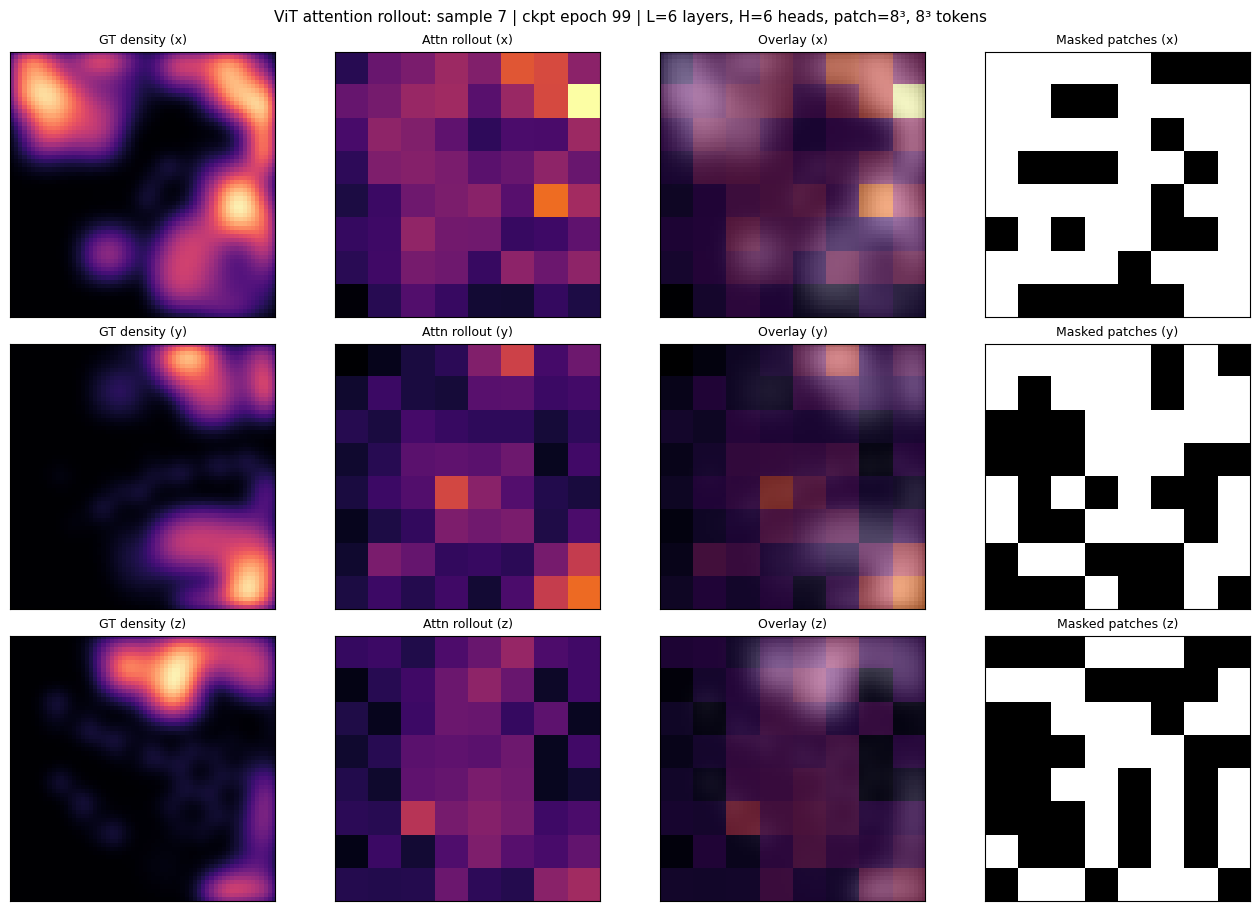

In [16]:
# ── plot: density GT | upsampled rollout heatmap | overlay ──────────────
# Upsample the (G_p, G_p, G_p) importance to (G, G, G) by patch-repeat
imp_full = np.repeat(np.repeat(np.repeat(imp_vol, BLOCK_SIZE, 0),
                                BLOCK_SIZE, 1), BLOCK_SIZE, 2)
mask_full_blocks = np.repeat(np.repeat(np.repeat(mask_blocks.astype(float), BLOCK_SIZE, 0),
                                       BLOCK_SIZE, 1), BLOCK_SIZE, 2)

vmin_i, vmax_i = imp_vol.min(), imp_vol.max()

fig, axes = plt.subplots(3, 4, figsize=(13, 9), constrained_layout=True)
for i, ax_name in enumerate(['x', 'y', 'z']):
    gt_sl = take_slice(d_clean_3d.cpu(), ax_name, SLICE_OFFSET)
    imp_sl = take_slice(imp_full, ax_name, SLICE_OFFSET)
    msk_sl = take_slice(mask_full_blocks, ax_name, SLICE_OFFSET)
    show(axes[i, 0], gt_sl, f'GT density ({ax_name})', cmap='magma',
         vmin=d_clean_3d.min().item(), vmax=d_clean_3d.max().item())
    show(axes[i, 1], imp_sl, f'Attn rollout ({ax_name})', cmap='inferno',
         vmin=vmin_i, vmax=vmax_i)
    # overlay: GT density (gray) + importance heat with alpha
    axes[i, 2].imshow(gt_sl.T, origin='lower', cmap='gray',
                      vmin=d_clean_3d.min().item(), vmax=d_clean_3d.max().item())
    axes[i, 2].imshow(imp_sl.T, origin='lower', cmap='inferno', alpha=0.55,
                      vmin=vmin_i, vmax=vmax_i)
    axes[i, 2].set_title(f'Overlay ({ax_name})', fontsize=9)
    axes[i, 2].set_xticks([]); axes[i, 2].set_yticks([])
    # masked-block map: 1 = masked (encoder sees zero), 0 = visible
    show(axes[i, 3], msk_sl, f'Masked patches ({ax_name})',
         cmap='Greys_r', vmin=0, vmax=1)
fig.suptitle(
    f"ViT attention rollout: sample {SAMPLE_IDX} | ckpt epoch {ckpt.get('epoch')} | "
    f"L={L_layers} layers, H={A_stack.shape[2]} heads, patch={BLOCK_SIZE}³, {G_p}³ tokens",
    fontsize=11,
)
plt.show()

visible patches (n=215): mean importance=0.00193  std=0.00044
masked  patches (n=297): mean importance=0.00197  std=0.00053
visible/masked ratio: 0.982x
  → ratio >> 1 means the rollout is dominated by visible (un-masked) patches,
    which is what you would expect once the encoder learned to ignore zeroed inputs.


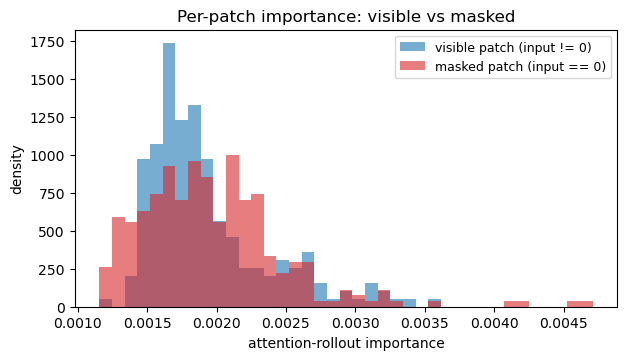

In [15]:
# ── attention statistics: visible vs masked patch importance ────────────
imp_flat = imp_vol.flatten()
msk_flat = mask_blocks.flatten()
vis_imp = imp_flat[~msk_flat]
msk_imp = imp_flat[msk_flat]
print(f'visible patches (n={vis_imp.size}): mean importance={vis_imp.mean():.5f}  std={vis_imp.std():.5f}')
print(f'masked  patches (n={msk_imp.size}): mean importance={msk_imp.mean():.5f}  std={msk_imp.std():.5f}')
print(f'visible/masked ratio: {vis_imp.mean() / max(msk_imp.mean(), 1e-9):.3f}x')
print('  → ratio >> 1 means the rollout is dominated by visible (un-masked) patches,')
print('    which is what you would expect once the encoder learned to ignore zeroed inputs.')

fig, ax = plt.subplots(figsize=(7, 3.6))
bins = np.linspace(imp_flat.min(), imp_flat.max(), 40)
ax.hist(vis_imp, bins=bins, alpha=0.6, color='C0', label='visible patch (input != 0)', density=True)
ax.hist(msk_imp, bins=bins, alpha=0.6, color='C3', label='masked patch (input == 0)', density=True)
ax.set_xlabel('attention-rollout importance')
ax.set_ylabel('density')
ax.legend(fontsize=9)
ax.set_title('Per-patch importance: visible vs masked')
plt.show()

## Notes

* `SAMPLE_IDX` ∈ [0, 99]. Re-run cells 4-end to swap sample.
* `CKPT_PATH` defaults to the rolling `checkpoint.pth.tar` — point to e.g. `checkpoint_e0050.pth.tar` to inspect a specific epoch.
* `SEED_MASK` matches `260520_density_mae_inspect.ipynb` (=0) so the same patches are masked → direct head-to-head with the cnn-MAE row of plots.
* The attention-rollout patch (cell 14) replaces every block's `attn.forward` with an explicit qk^T softmax that records weights. The patched forward is verified bit-equal to the fused SDPA forward (`atol=1e-4`) before trusting the rollout.
* If the visible/masked importance ratio in cell 17 ≈ 1.0, the encoder hasn't yet learned to discount zeroed inputs and is treating masked patches as informative — usually a sign the model is undertrained.
* If you want **per-layer** attention (instead of the L-step rollout), `attn_weights[l]` holds layer-l's full `(B, H, N, N)` after cell 14.